# goal

make it accept multiple aircraft from csv and make it so that i can sahre like entire folder of data and it wokrs 

and everything is reusable for x no.

forgot- need to work on the dead zones as well - use pomdp maybe

gap>60sec

In [211]:
import pandas as pd
import numpy as np
import os
import webbrowser

# visualisation
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# mesa
from mesa import Agent, Model
from mesa.time import BaseScheduler

In [212]:
DATA_FOLDER = r"C:\Users\Dev Sharma\OneDrive\Documents\MDP\Datasets\Validation data (FlightRader24)"

In [213]:
aircraft_data = {} # ye meri storage dictionary ho jayegi




In [214]:
for file in os.listdir(DATA_FOLDER):

    if file.endswith(".csv"):
        path = os.path.join(DATA_FOLDER, file)
        df = pd.read_csv(path)

        # vahi basic data changes 
        df["UTC"] = pd.to_datetime(df["UTC"])
        df[['lat','lon']] = df['Position'].str.split(',', expand=True).astype(float)

        # agar combined data hua toh fir
        if "Callsign" in df.columns:
            groups = df.groupby("Callsign")
            for callsign, group in groups:
                aircraft_data[callsign] = group.sort_values("UTC").reset_index(drop=True)

        else:
            callsign = file.replace(".csv","")
            aircraft_data[callsign] = df.sort_values("UTC").reset_index(drop=True)

In [215]:
len(aircraft_data)


11

In [216]:
aircraft_data.keys()

dict_keys(['AAL1028', 'AAL917', 'AZU8708', 'AMX410', 'JBU1052', 'BWA035', 'DAL1812', 'UAL1020', 'SWG388', 'SWG5417', 'SWA219'])

In [217]:
# df = pd.read_csv( r"C:\Users\Dev Sharma\OneDrive\Documents\MDP\Datasets\Combined_Aircraft_Tracking.csv")

# print("Rows loaded:", len(df))
# df

In [218]:
# df["UTC"] = pd.to_datetime(df["UTC"])
# df["lat"] = None
# df["lon"] = None

# # for i, pos in enumerate(df["Position"]):

# #     lat_str, lon_str = pos.split(",")
# #     df.at[i, "lat"] = float(lat_str)
# #     df.at[i, "lon"] = float(lon_str)

# df[['lat','lon']] = df['Position'].str.split(',', expand=True).astype(float)



# df = df.sort_values(["Callsign", "UTC"]).reset_index(drop=True)

In [219]:
df

,Timestamp,UTC,Callsign,Position,Altitude,Speed,Direction,lat,lon
0,1741301897,2025-03-06 22:58:17+00:00,SWA219,"21.048409,-86.880356",0,0,255,21.048409,-86.880356
1,1741302422,2025-03-06 23:07:02+00:00,SWA219,"21.048466,-86.880135",0,2,253,21.048466,-86.880135
2,1741302779,2025-03-06 23:12:59+00:00,SWA219,"21.050188,-86.880928",0,0,303,21.050188,-86.880928
3,1741303538,2025-03-06 23:25:38+00:00,SWA219,"21.032272,-86.870293",175,168,124,21.032272,-86.870293
4,1741303545,2025-03-06 23:25:45+00:00,SWA219,"21.029205,-86.865417",450,169,123,21.029205,-86.865417
...,...,...,...,...,...,...,...,...,...
1371,1741319760,2025-03-07 03:56:00+00:00,SWA219,"41.785686,-87.744339",0,14,42,41.785686,-87.744339
1372,1741319770,2025-03-07 03:56:10+00:00,SWA219,"41.786133,-87.743774",0,10,45,41.786133,-87.743774
1373,1741319779,2025-03-07 03:56:19+00:00,SWA219,"41.786385,-87.743416",0,8,47,41.786385,-87.743416
1374,1741319788,2025-03-07 03:56:28+00:00,SWA219,"41.786556,-87.743202",0,4,45,41.786556,-87.743202


In [220]:
# df.distince("callsign")

df["Callsign"].unique()


<StringArray>
['SWA219']
Length: 1, dtype: str

In [221]:
# aircraft_data = {}

# groups = df.groupby("Callsign")

# for callsign, group in groups:

#     aircraft_data[callsign] = group.reset_index(drop=True)

# print("Aircraft found:", list(aircraft_data.keys()))

In [222]:
# ye bas total start to end distance de reha hai for each

# more general

def haversine(lat1, lon1, lat2, lon2):

    R = 3440  # nautical miles

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    distance = 2 * R * np.arcsin(np.sqrt(a))
    return (distance)


for callsign, df in aircraft_data.items():

    dist = haversine(
        df["lat"].iloc[0],
        df["lon"].iloc[0],
        df["lat"].iloc[-1],
        df["lon"].iloc[-1]
    )

    print(callsign, "distance:", dist, "nm")

AAL1028 distance: 987.1177144960478 nm
AAL917 distance: 2278.3971249605916 nm
AZU8708 distance: 3665.957985561179 nm
AMX410 distance: 1805.5370560552885 nm
JBU1052 distance: 536.6557518220262 nm
BWA035 distance: 522.8165187511711 nm
DAL1812 distance: 2095.9303697853884 nm
UAL1020 distance: 706.4014781497935 nm
SWG388 distance: 1202.6231927341687 nm
SWG5417 distance: 1406.5050081437719 nm
SWA219 distance: 1245.8801954000019 nm


In [223]:
class AircraftAgent(Agent):

    def __init__(self, unique_id, model, trajectory):
        super().__init__(unique_id, model)

        self.trajectory = trajectory
        self.step_index = 0
        self.history_time = [0]

        # starting position
        self.lat = trajectory["lat"].iloc[0]
        self.lon = trajectory["lon"].iloc[0]

        # aircraft state
        self.altitude = trajectory["Altitude"].iloc[0]
        self.speed = trajectory["Speed"].iloc[0]

        # keep history for plotting
        self.history_lat = [self.lat]
        self.history_lon = [self.lon]


    def step(self):
        if self.step_index < len(self.trajectory) - 1:

            self.step_index += 1

            row = self.trajectory.iloc[self.step_index]

            self.lat = row.lat
            self.lon = row.lon
            self.altitude = row.Altitude
            self.speed = row.Speed

            self.history_lat.append(self.lat)
            self.history_lon.append(self.lon)
            self.history_time.append(self.model.time)

tfr boundry

In [224]:
class TFRZone:

    def __init__(self, lat, lon, radius_nm):

        self.lat = lat
        self.lon = lon
        self.radius = radius_nm

isme mai air traffic separtion bhi dal reha hu for now

iska future use hoga ig ki

baseline replay vs policy-controlled trajectories kaise hota hai

plus future metrics

3nm cause ai bola

In [225]:
class AirTrafficModel(Model):

    def __init__(self, aircraft_data):
        super().__init__()
        self.schedule = BaseScheduler(self)
        self.time = 0
        self.aircraft_agents = []

        # TFR zone (Starship launch)
        self.tfr = TFRZone(
            lat=28.4889,
            lon=-80.5778,
            radius_nm=30
        )

        self.violations = []
        self.separation_violations = []

        for callsign, df in aircraft_data.items():
            agent = AircraftAgent(callsign, self, df)
            self.schedule.add(agent)
            self.aircraft_agents.append(agent)


    def step(self):
        self.schedule.step()
        self.time += 1

        # check TFR violations
        for aircraft in self.aircraft_agents:
            d = haversine(
                aircraft.lat,
                aircraft.lon,
                self.tfr.lat,
                self.tfr.lon
            )

            if d < self.tfr.radius:

                self.violations.append(
                    (aircraft.unique_id, self.time, d)) # forgot that time is global vs step idx being agent specific
                print("TFR violation:", aircraft.unique_id)
        

        # check aircraft separation
        for i in range(len(self.aircraft_agents)):
            for j in range(i + 1, len(self.aircraft_agents)):

                a1 = self.aircraft_agents[i]
                a2 = self.aircraft_agents[j]

                d = haversine(
                    a1.lat, a1.lon,
                    a2.lat, a2.lon)

                if d < 3:  # 3 nautical miles

                    self.separation_violations.append(
                        (a1.unique_id, a2.unique_id, self.time, d)
                    )

                    print(
                        "Separation violation:",
                        a1.unique_id,
                        a2.unique_id,
                        "time:", self.time,
                        "distance:", d
                    )

note - global simulation time for the entire environment

sab safety event should refer to the env time kyuki conflict involves multi aircraft all together

In [226]:
model = AirTrafficModel(aircraft_data)

# number of steps = longest flight
max_steps = 0

for df in aircraft_data.values():

    if len(df) > max_steps:
        max_steps = len(df)

print("Simulation steps:", max_steps)

for i in range(max_steps - 1):

    model.step()

print("Simulation finished")

Simulation steps: 1912
Separation violation: JBU1052 SWA219 time: 1 distance: 1.7146806861243256
Separation violation: JBU1052 SWA219 time: 2 distance: 2.114202863679427
Separation violation: JBU1052 SWA219 time: 3 distance: 1.3569270842577903
Separation violation: JBU1052 SWA219 time: 4 distance: 1.4447915627441843
Separation violation: JBU1052 SWA219 time: 5 distance: 1.4627979579331023
Separation violation: JBU1052 SWA219 time: 6 distance: 1.5322525443175106
Separation violation: JBU1052 SWA219 time: 7 distance: 1.558270875470575
Separation violation: JBU1052 SWA219 time: 8 distance: 1.490290215415813
Separation violation: JBU1052 SWA219 time: 9 distance: 1.691203769312165
Separation violation: JBU1052 SWA219 time: 10 distance: 2.16000932105283
Separation violation: JBU1052 SWA219 time: 11 distance: 2.461630440169614
Separation violation: JBU1052 SWA219 time: 12 distance: 2.9546556508372266
Separation violation: JBU1052 SWA219 time: 79 distance: 0.24692305429024117
Separation violat

In [227]:
print("Total violations:", len(model.violations))

for v in model.violations:
    print(v)

Total violations: 44
('JBU1052', 1157, np.float64(28.57526002999095))
('JBU1052', 1158, np.float64(26.357241228563154))
('JBU1052', 1159, np.float64(24.44310933039776))
('JBU1052', 1160, np.float64(22.69320593024147))
('JBU1052', 1161, np.float64(21.17299110482639))
('JBU1052', 1162, np.float64(20.208403587854427))
('JBU1052', 1163, np.float64(20.089810434526704))
('JBU1052', 1164, np.float64(19.99082185928802))
('JBU1052', 1165, np.float64(19.89000424258999))
('JBU1052', 1166, np.float64(19.802519120148855))
('JBU1052', 1167, np.float64(19.68492875010368))
('JBU1052', 1168, np.float64(19.58988582265685))
('JBU1052', 1169, np.float64(19.49261689603413))
('JBU1052', 1170, np.float64(19.39196589645718))
('JBU1052', 1171, np.float64(18.10499395744404))
('JBU1052', 1172, np.float64(17.19024002775595))
('JBU1052', 1173, np.float64(16.900439350488305))
('JBU1052', 1174, np.float64(16.71200656115604))
('JBU1052', 1175, np.float64(16.624274204036677))
('JBU1052', 1176, np.float64(16.5935668755

In [228]:
print("Total separation violations:", len(model.separation_violations))

Total separation violations: 1005


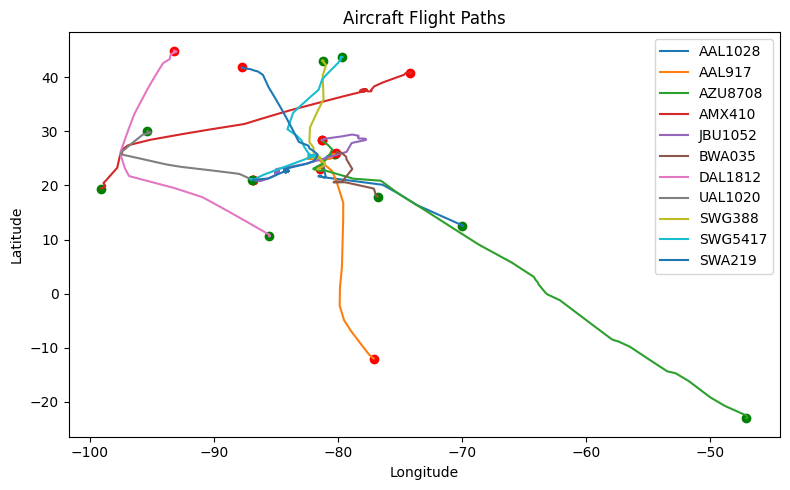

In [229]:
plt.figure(figsize=(8,5))

for callsign, df in aircraft_data.items():

    plt.plot(df["lon"], df["lat"], label=callsign)

    plt.scatter(df["lon"].iloc[0], df["lat"].iloc[0], color="green")
    plt.scatter(df["lon"].iloc[-1], df["lat"].iloc[-1], color="red")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Aircraft Flight Paths")

plt.legend()

plt.tight_layout()

#plt.savefig("flight_paths.png", dpi=150)

plt.show()

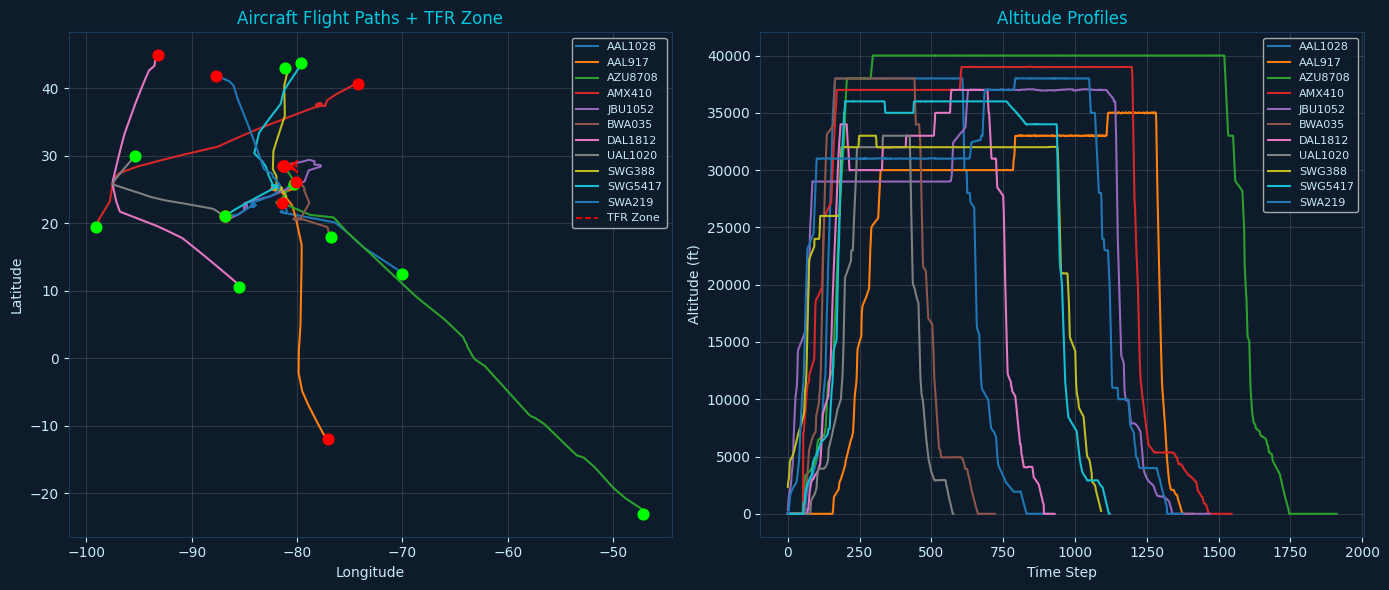

In [230]:
fig_mpl, axes = plt.subplots(1, 2, figsize=(14, 6))
fig_mpl.patch.set_facecolor('#0d1b2a')
 
# ── Left: flight paths ──
ax1 = axes[0]
ax1.set_facecolor('#0d1b2a')
 
for callsign, df in aircraft_data.items():
    ax1.plot(df["lon"], df["lat"], linewidth=1.5, label=callsign)
    ax1.scatter(df["lon"].iloc[0],  df["lat"].iloc[0],  color="lime",  zorder=5, s=60)
    ax1.scatter(df["lon"].iloc[-1], df["lat"].iloc[-1], color="red",   zorder=5, s=60)
 
# TFR zone circle
tfr = model.tfr
tfr_angles = np.linspace(0, 2 * np.pi, 100)
# rough degree conversion: 1 nm ≈ 1/60 degree
tfr_radius_deg = tfr.radius / 60
tfr_lons = tfr.lon + tfr_radius_deg * np.cos(tfr_angles)
tfr_lats = tfr.lat + tfr_radius_deg * np.sin(tfr_angles)
ax1.fill(tfr_lons, tfr_lats, color='red', alpha=0.15, zorder=3)
ax1.plot(tfr_lons, tfr_lats, color='red', linewidth=1.2, linestyle='--', zorder=4, label='TFR Zone')
ax1.scatter([tfr.lon], [tfr.lat], color='red', marker='x', s=80, zorder=5)
 
ax1.set_xlabel("Longitude", color='#c8eaf5')
ax1.set_ylabel("Latitude",  color='#c8eaf5')
ax1.set_title("Aircraft Flight Paths + TFR Zone", color='#00c8e0')
ax1.tick_params(colors='#c8eaf5')
ax1.legend(facecolor='#0d1b2a', labelcolor='#c8eaf5', fontsize=8)
ax1.grid(True, alpha=0.2)
for spine in ax1.spines.values():
    spine.set_edgecolor('#1a3a5c')
 
# ── Right: altitude profiles per aircraft ──
ax2 = axes[1]
ax2.set_facecolor('#0d1b2a')
 
for callsign, df in aircraft_data.items():
    ax2.plot(range(len(df)), df["Altitude"], linewidth=1.5, label=callsign)
 
ax2.set_xlabel("Time Step",    color='#c8eaf5')
ax2.set_ylabel("Altitude (ft)", color='#c8eaf5')
ax2.set_title("Altitude Profiles", color='#00c8e0')
ax2.tick_params(colors='#c8eaf5')
ax2.legend(facecolor='#0d1b2a', labelcolor='#c8eaf5', fontsize=8)
ax2.grid(True, alpha=0.2)
for spine in ax2.spines.values():
    spine.set_edgecolor('#1a3a5c')
 
plt.tight_layout()
plt.show()
 


In [232]:
COLOURS = ['#00c8e0', '#ff9d00', '#00ff9d', '#ff4488', '#bf55ff']
 
def hex_rgba(hex_color, alpha=1.0):
    h = hex_color.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'
 
fig = go.Figure()
 
all_lat = pd.concat([d["lat"] for d in aircraft_data.values()])
all_lon = pd.concat([d["lon"] for d in aircraft_data.values()])
mid_lat = (all_lat.max() + all_lat.min()) / 2
mid_lon = (all_lon.max() + all_lon.min()) / 2
 
for idx, (cs, data) in enumerate(aircraft_data.items()):
    colour = COLOURS[idx % len(COLOURS)]
 
    # Faint path line
    fig.add_trace(go.Scattergeo(
        lat=data['lat'], lon=data['lon'],
        mode='lines',
        line=dict(width=1.5, color=hex_rgba(colour, 0.3)),
        hoverinfo='skip',
        showlegend=False,
    ))
 
    # Dots coloured by altitude
    fig.add_trace(go.Scattergeo(
        lat=data['lat'], lon=data['lon'],
        mode='markers',
        marker=dict(
            size=5,
            color=data['Altitude'],
            colorscale=[
                [0.0, '#0a0f2e'],
                [0.3, hex_rgba(colour, 0.6)],
                [0.7, colour],
                [1.0, '#ffffff'],
            ],
            cmin=0, cmax=40000,
            showscale=False,
            opacity=0.9,
        ),
        text=[
            f"<b>{cs}</b><br>"
            f"⏱  {r.UTC.strftime('%H:%M:%S')} UTC<br>"
            f"✈  {int(r.Altitude):,} ft<br>"
            f"💨 {int(r.Speed)} kts<br>"
            f"🧭 {int(r.Direction)}°"
            for _, r in data.iterrows()
        ],
        hoverinfo='text',
        hoverlabel=dict(
            bgcolor='#050c1c', bordercolor=colour,
            font=dict(color='#c8eaf5', size=12, family='Courier New'),
        ),
        name=cs,
        showlegend=True,
    ))
 
    # Departure marker ●
    fig.add_trace(go.Scattergeo(
        lat=[data['lat'].iloc[0]], lon=[data['lon'].iloc[0]],
        mode='markers',
        marker=dict(size=12, color=colour, symbol='circle',
                    line=dict(color='white', width=2)),
        hovertext=f"<b>DEPARTURE — {cs}</b><br>{data['lat'].iloc[0]:.3f}°N  {abs(data['lon'].iloc[0]):.3f}°W",
        hoverinfo='text',
        showlegend=False,
    ))
 
    # Arrival marker ■
    fig.add_trace(go.Scattergeo(
        lat=[data['lat'].iloc[-1]], lon=[data['lon'].iloc[-1]],
        mode='markers',
        marker=dict(size=12, color=colour, symbol='square',
                    line=dict(color='white', width=2)),
        hovertext=f"<b>ARRIVAL — {cs}</b><br>{data['lat'].iloc[-1]:.3f}°N  {abs(data['lon'].iloc[-1]):.3f}°W",
        hoverinfo='text',
        showlegend=False,
    ))
 
# TFR zone ring
tfr_angles = np.linspace(0, 2 * np.pi, 72)
tfr_radius_deg = model.tfr.radius / 60
tfr_ring_lats = model.tfr.lat + tfr_radius_deg * np.sin(tfr_angles)
tfr_ring_lons = model.tfr.lon + tfr_radius_deg * np.cos(tfr_angles)
 
fig.add_trace(go.Scattergeo(
    lat=np.append(tfr_ring_lats, tfr_ring_lats[0]),
    lon=np.append(tfr_ring_lons, tfr_ring_lons[0]),
    mode='lines',
    line=dict(color='rgba(255,60,60,0.8)', width=2, dash='dash'),
    hoverinfo='skip',
    name='TFR Zone',
    showlegend=True,
))
 
fig.add_trace(go.Scattergeo(
    lat=[model.tfr.lat], lon=[model.tfr.lon],
    mode='markers+text',
    marker=dict(size=10, color='red', symbol='x'),
    text=['TFR'], textposition='top right',
    textfont=dict(color='red', family='Courier New', size=11),
    hovertext=f"TFR Centre<br>{model.tfr.lat}°N  {abs(model.tfr.lon):.2f}°W<br>Radius: {model.tfr.radius} nm",
    hoverinfo='text',
    showlegend=False,
))
 
# Separation violation markers
if model.separation_violations:
    # just mark where each pair was at the time of first violation
    seen = set()
    for v in model.separation_violations:
        pair = (v[0], v[1])
        if pair not in seen:
            seen.add(pair)
            a1 = next(a for a in model.aircraft_agents if a.unique_id == v[0])
            a2 = next(a for a in model.aircraft_agents if a.unique_id == v[1])
            mid_v_lat = (a1.lat + a2.lat) / 2
            mid_v_lon = (a1.lon + a2.lon) / 2
            fig.add_trace(go.Scattergeo(
                lat=[mid_v_lat], lon=[mid_v_lon],
                mode='markers',
                marker=dict(size=14, color='yellow', symbol='triangle-up',
                            line=dict(color='orange', width=1.5)),
                hovertext=f"⚠ Separation violation<br>{v[0]} — {v[1]}<br>Dist: {v[3]:.2f} nm",
                hoverinfo='text',
                showlegend=False,
            ))
 
# Map style
fig.update_geos(
    projection=dict(type='orthographic',
                    rotation=dict(lon=mid_lon, lat=mid_lat)),
    center=dict(lat=mid_lat, lon=mid_lon),
    showland=True,       landcolor='#0d1b2a',
    showocean=True,      oceancolor='#060d1a',
    showlakes=True,      lakecolor='#081422',
    showcountries=True,  countrycolor='rgba(60,100,160,0.5)',  countrywidth=0.6,
    showcoastlines=True, coastlinecolor='rgba(0,140,200,0.7)', coastlinewidth=1,
    showsubunits=True,   subunitcolor='rgba(40,80,130,0.4)',   subunitwidth=0.5,
    lonaxis=dict(range=[all_lon.min() - 4, all_lon.max() + 4]),
    lataxis=dict(range=[all_lat.min() - 4, all_lat.max() + 4]),
    bgcolor='#030810',
)
 
fig.update_layout(
    title=dict(text='Aircraft Trajectories', font=dict(color='#00c8e0', family='Courier New')),
    paper_bgcolor='#030810',
    legend=dict(
        font=dict(color='#c8eaf5', family='Courier New'),
        bgcolor='rgba(4,12,26,0.8)',
        bordercolor='rgba(0,180,220,0.3)',
        borderwidth=1,
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    height=800,
)
 
fig.write_html('aircraft_map.html', config={'scrollZoom': True, 'displaylogo': False})
webbrowser.open('file://' + os.path.abspath('aircraft_map.html'))


True

### things to do rn

1. sab aircraft abhi like stop toh hoja rehi hai lekin abhi bhi part of simulation hai

2. abhi sab aircraft follow kar rehi hai trajectory based on data provided 

but baadmaai jab action hoga for the agents tab mujhe ye logic change karna hoga

3. too many repeated violations - isko sahi karna hai

4. Wheneven these is a conflict -  do altitude separation
-Predict conflicts 20 steps ahead
-Allow agents to choose actions like climb, descend, turn and slow